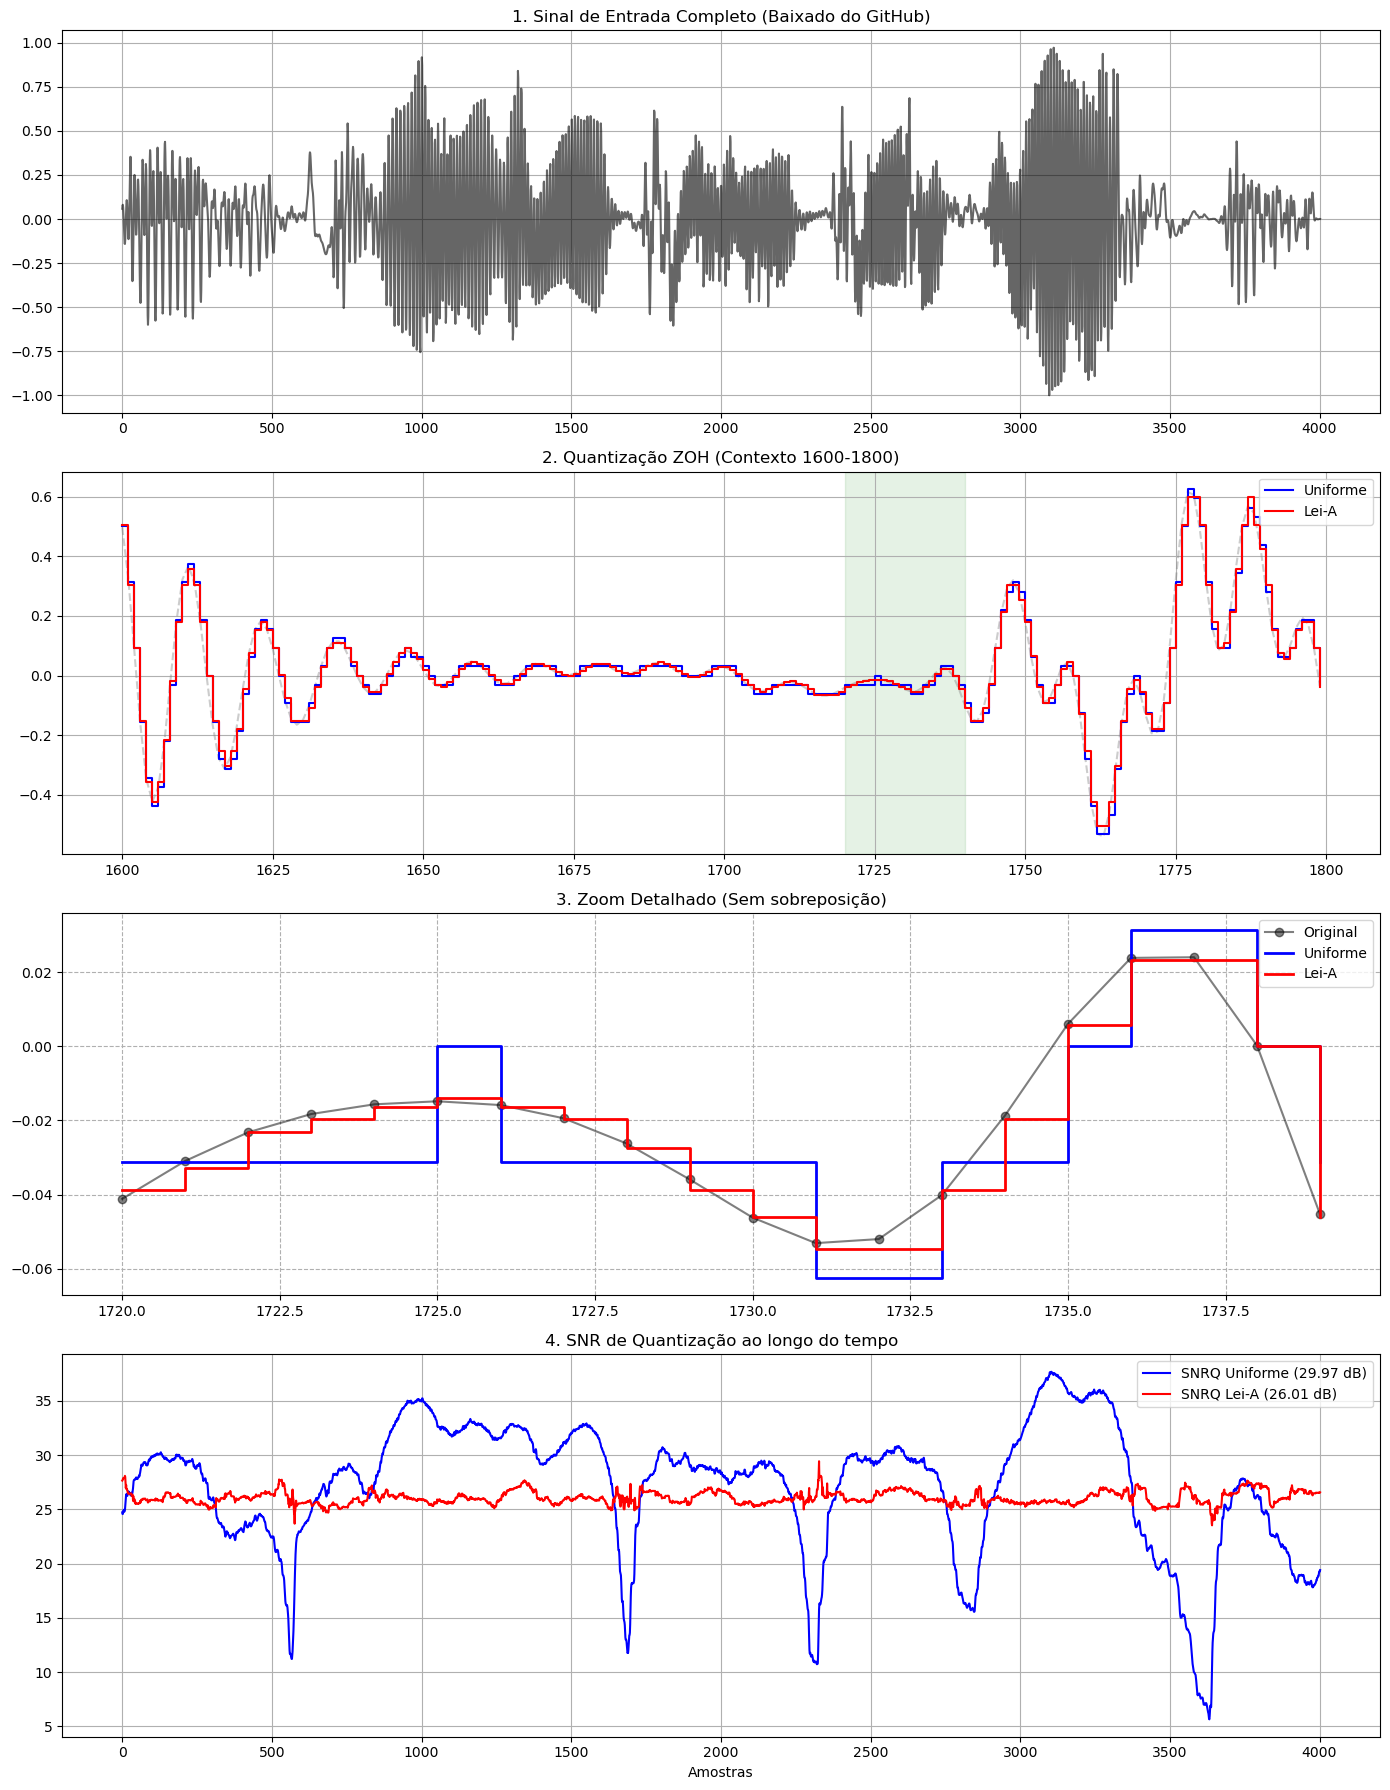

--- Sucesso! ---
SNR Uniforme: 29.97 dB | SNR Lei-A: 26.01 dB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO

# 1. Função para carregar dados direto da Web (GitHub)
def load_data_from_url(url):
    response = requests.get(url)
    if response.status_code == 200:
        # BytesIO transforma o conteúdo baixado em um "arquivo virtual" para o numpy
        data = np.loadtxt(BytesIO(response.content), skiprows=1)
        return data
    else:
        raise Exception(f"Erro ao baixar arquivo: Status {response.status_code}")

# 2. Funções da Lei-A
def a_law_compress(x, A=87.56):
    x_abs = np.abs(x)
    y = np.where(x_abs < 1/A,
                 (A * x_abs) / (1 + np.log(A)),
                 (1 + np.log(A * x_abs)) / (1 + np.log(A)))
    return np.sign(x) * y

def a_law_expand(y, A=87.56):
    y_abs = np.abs(y)
    limit = 1 / (1 + np.log(A))
    x = np.where(y_abs < limit,
                 (y_abs * (1 + np.log(A))) / A,
                 np.exp(y_abs * (1 + np.log(A)) - 1) / A)
    return np.sign(y) * x

# 3. Quantizador Uniforme
def uniform_quantizer(signal, bits):
    levels = 2**bits
    signal_clipped = np.clip(signal, -1, 1)
    step = 2 / levels
    quantized = np.round((signal_clipped + 1) / step) * step - 1
    return np.clip(quantized, -1, 1)

# 4. Cálculo de Métricas (SNR)
def calculate_metrics(original, quantized):
    error = original - quantized
    mse = np.mean(error**2)
    signal_power = np.mean(original**2)
    snr = 10 * np.log10(signal_power / (mse + 1e-10))
    return error, snr

# 5. SNR Temporal
def running_snr(original, quantized, window_size=100):
    error = original - quantized
    signal_pow = np.convolve(original**2, np.ones(window_size)/window_size, mode='same')
    noise_pow = np.convolve(error**2, np.ones(window_size)/window_size, mode='same')
    return 10 * np.log10(signal_pow / (noise_pow + 1e-10))

# --- Execução Principal no Colab ---

# COLE AQUI A SUA URL "RAW" DO GITHUB
github_url = "https://raw.githubusercontent.com/luiz10ml/T27--Digital-Communication/main/Quantizer/VoiceFiltered.dat"

try:
    input_signal = load_data_from_url(github_url)
    
    # Normalização
    input_signal = input_signal / np.max(np.abs(input_signal))

    A = 87.56
    bits = 6

    # A. Quantização Uniforme
    quant_uni = uniform_quantizer(input_signal, bits)
    _, snr_uni = calculate_metrics(input_signal, quant_uni)

    # B. Quantização Não-Uniforme (Lei-A)
    compressed = a_law_compress(input_signal, A)
    quant_compressed = uniform_quantizer(compressed, bits)
    expanded = a_law_expand(quant_compressed, A)
    _, snr_non_uni = calculate_metrics(input_signal, expanded)

    # --- Plotagem com 4 Subplots ---
    t = np.arange(len(input_signal))
    fig, axes = plt.subplots(4, 1, figsize=(14, 18))

    # Subplot 1: Sinal Completo
    axes[0].plot(t, input_signal, color='black', alpha=0.6)
    axes[0].set_title('1. Sinal de Entrada Completo (Baixado do GitHub)')
    axes[0].grid(True)

    # Subplot 2: Trecho de Contexto
    start_ctx, end_ctx = 1600, 1800
    axes[1].plot(t[start_ctx:end_ctx], input_signal[start_ctx:end_ctx], color='gray', linestyle='--', alpha=0.4)
    axes[1].step(t[start_ctx:end_ctx], quant_uni[start_ctx:end_ctx], where='post', label='Uniforme', color='blue')
    axes[1].step(t[start_ctx:end_ctx], expanded[start_ctx:end_ctx], where='post', label='Lei-A', color='red')
    axes[1].set_title(f'2. Quantização ZOH (Contexto {start_ctx}-{end_ctx})')
    axes[1].legend(loc='upper right')
    axes[1].grid(True)
    axes[1].axvspan(1720, 1740, color='green', alpha=0.1)

    # Subplot 3: ZOOM SEM SOBREPOSIÇÃO (1720-1740)
    start_z, end_z = 1720, 1740
    axes[2].plot(t[start_z:end_z], input_signal[start_z:end_z], color='black', marker='o', alpha=0.5, label='Original')
    axes[2].step(t[start_z:end_z], quant_uni[start_z:end_z], where='post', color='blue', linewidth=2, label='Uniforme')
    axes[2].step(t[start_z:end_z], expanded[start_z:end_z], where='post', color='red', linewidth=2, label='Lei-A')
    axes[2].set_title('3. Zoom Detalhado (Sem sobreposição)')
    axes[2].legend()
    axes[2].grid(True, linestyle='--')

    # Subplot 4: SNRQ Temporal
    snr_t_uni = running_snr(input_signal, quant_uni)
    snr_t_non = running_snr(input_signal, expanded)
    axes[3].plot(t, snr_t_uni, label=f'SNRQ Uniforme ({snr_uni:.2f} dB)', color='blue')
    axes[3].plot(t, snr_t_non, label=f'SNRQ Lei-A ({snr_non_uni:.2f} dB)', color='red')
    axes[3].set_title('4. SNR de Quantização ao longo do tempo')
    axes[3].set_xlabel('Amostras')
    axes[3].legend()
    axes[3].grid(True)

    plt.tight_layout()
    plt.show()

    print(f"--- Sucesso! ---")
    print(f"SNR Uniforme: {snr_uni:.2f} dB | SNR Lei-A: {snr_non_uni:.2f} dB")

except Exception as e:
    print(e)